# LSTM Hybrid Autoencoder with SWaT 2020

In [1]:
import os
import json
import joblib
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

## Carga de datos

In [2]:
clean_folder = Path("../data/clean/SWaT.A7_June2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {path.stem: load_clean_csv(path) for path in file_paths}

print("Archivos cargados:")
list(files.keys())

Archivos cargados:


['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']

In [3]:
clean_folder = Path("../data/clean/SWaT.A7_June2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {path.stem: load_clean_csv(path) for path in file_paths}

print("Archivos cargados:")
list(files.keys())

Archivos cargados:


['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']

In [4]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}

print("Número de columnas comunes:", len(common_cols))

Número de columnas comunes: 61


## Eliminar filas vacias

In [5]:
temp_feature_cols = [c for c in next(iter(files.values())).columns if c != "t_stamp"]

for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=temp_feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])

    if before != after:
        print(f"{name}: se eliminaron {before - after} filas completamente vacías")

29June2020_2: se eliminaron 1 filas completamente vacías


## Reproducibilidad

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Identificar variables

In [7]:
sample_df = next(iter(files.values()))

continuous_cols = [c for c in sample_df.columns if ".Pv" in c]
discrete_cols   = [c for c in sample_df.columns if (".Status" in c or "_STATE" in c)]

feature_cols = continuous_cols + discrete_cols

print("Continuas:", len(continuous_cols))
print("Discretas:", len(discrete_cols))

Continuas: 25
Discretas: 35


In [8]:
summary_rows = []

for name, df in files.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": df.shape[1],
        "start_time": df["t_stamp"].min(),
        "end_time": df["t_stamp"].max(),
        "missing_total": int(df.isna().sum().sum())
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7200,61,2020-06-29 13:30:00,2020-06-29 15:29:59.000,0


## Visualización temporal por día

In [9]:
def plot_sensor_time_series_by_day(files, sensor_col):
    day_groups = {
        "22June2020": ["22June2020_2", "22June2020_1"],
        "29June2020": ["29June2020_1", "29June2020_2"]
    }

    for day, file_list in day_groups.items():
        plt.figure(figsize=(12, 4))

        for fname in file_list:
            if fname in files:
                df = files[fname]
                plt.plot(df["t_stamp"], df[sensor_col], label=fname)

        plt.title(f"{sensor_col} - {day}")
        plt.xlabel("Tiempo")
        plt.ylabel(sensor_col)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

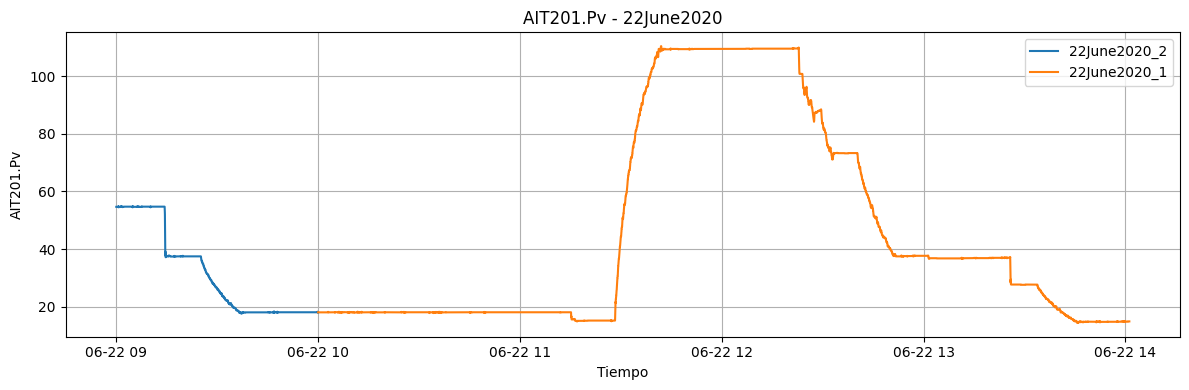

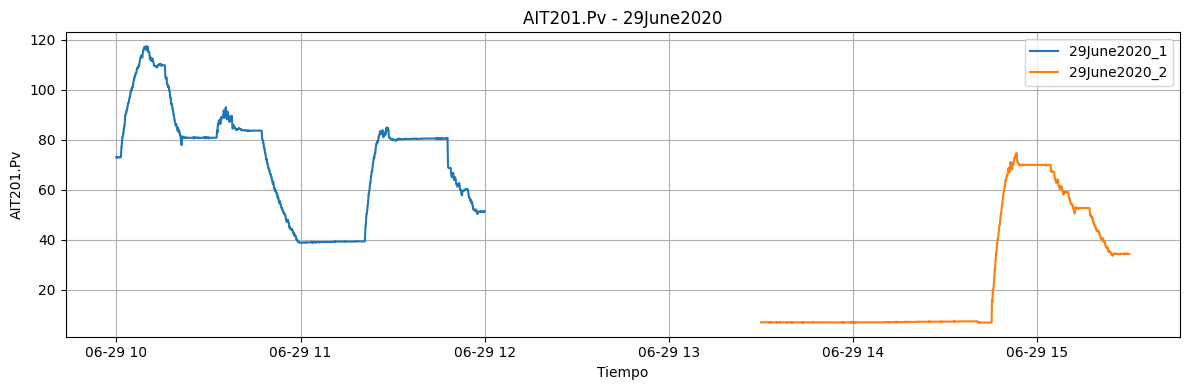

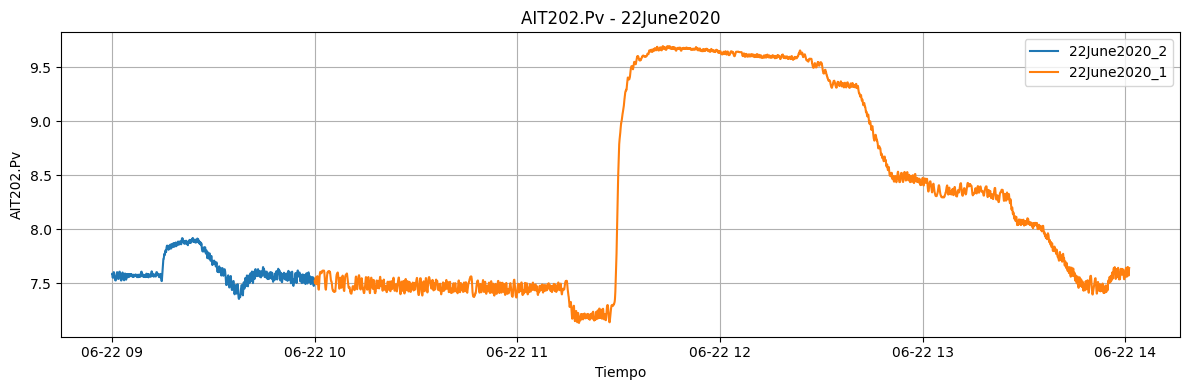

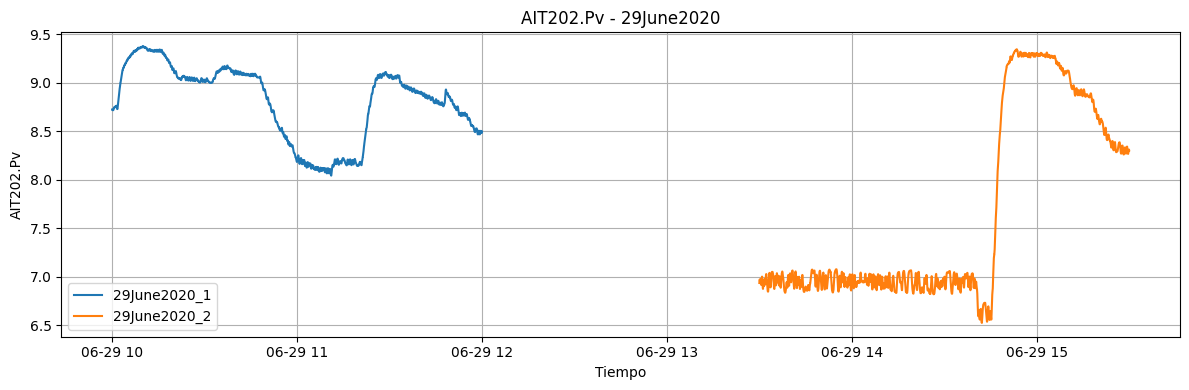

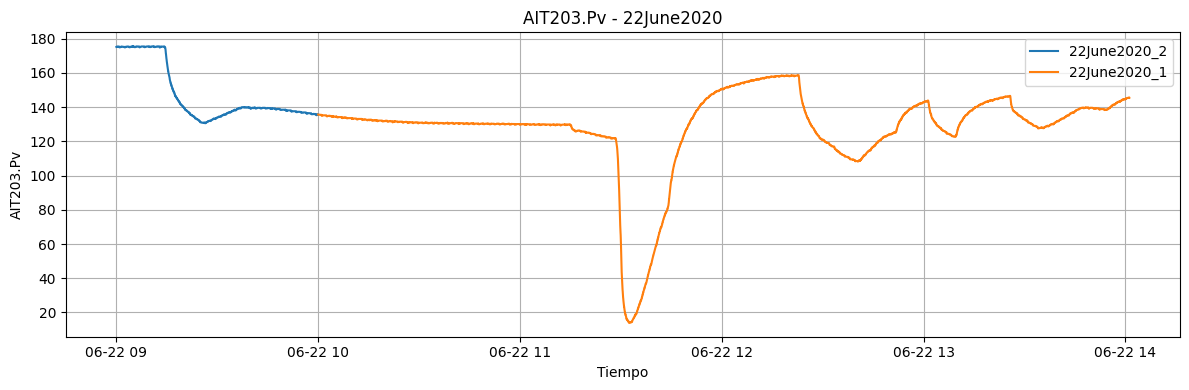

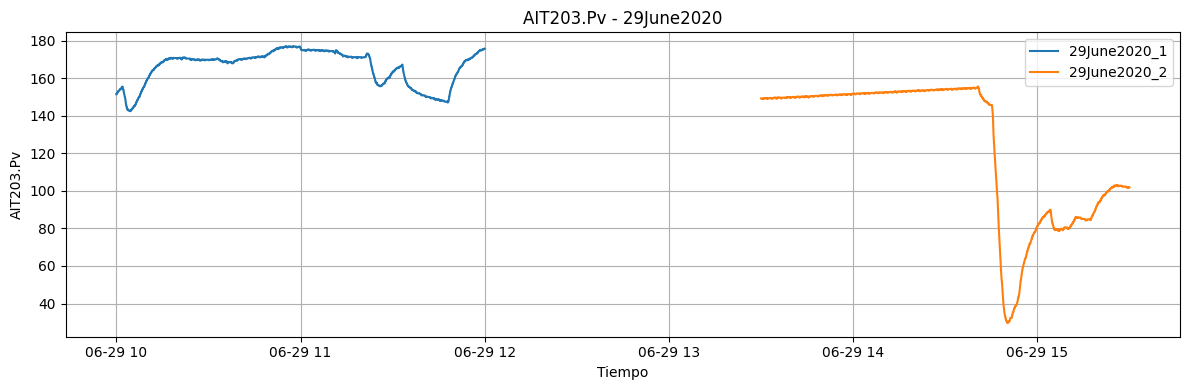

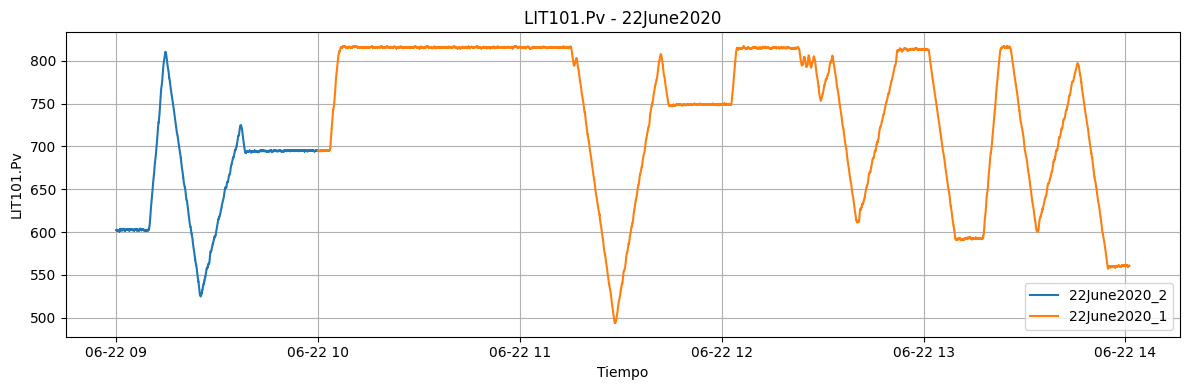

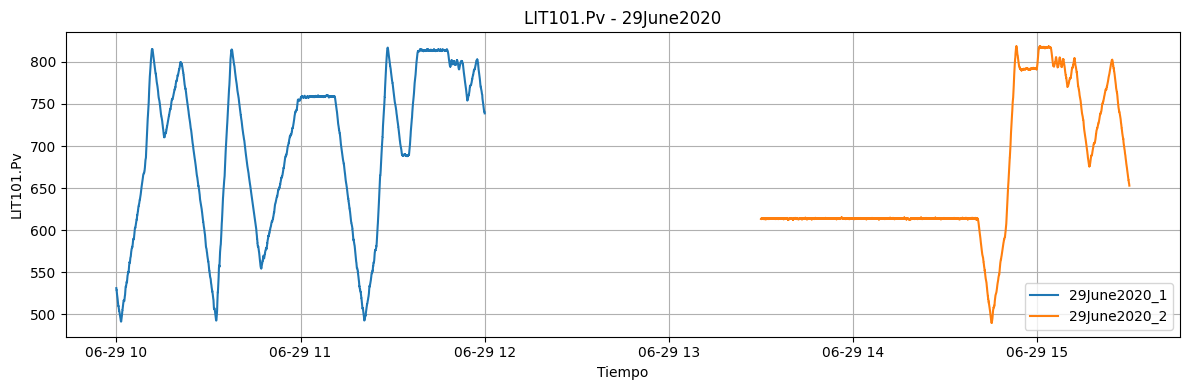

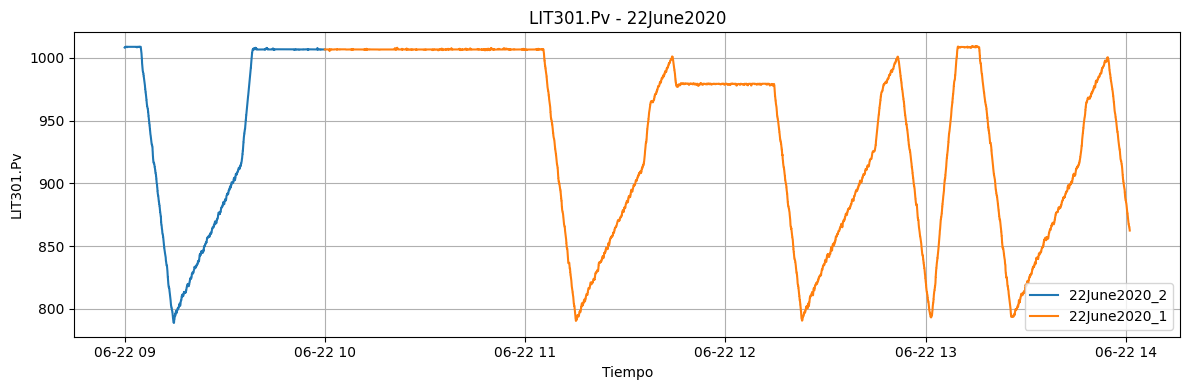

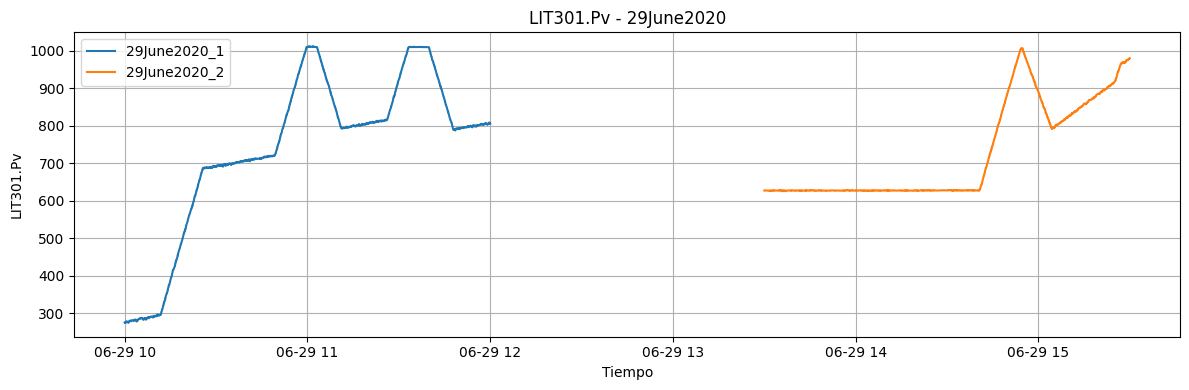

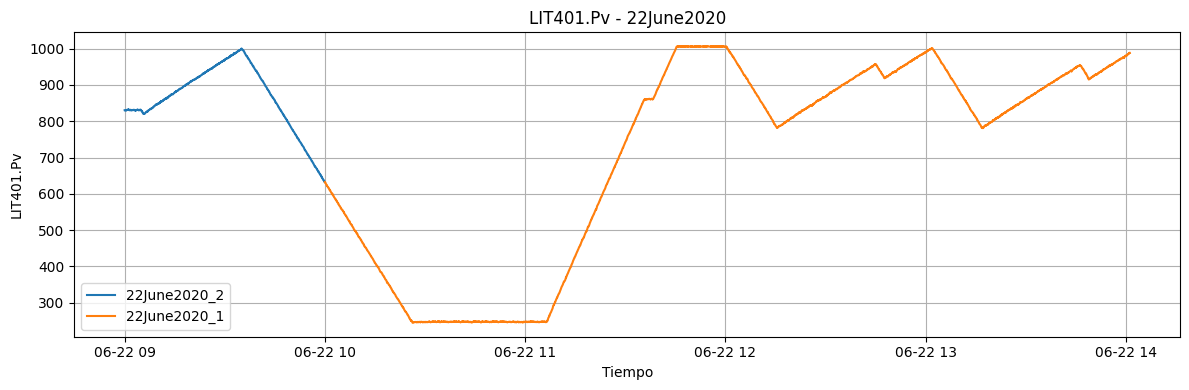

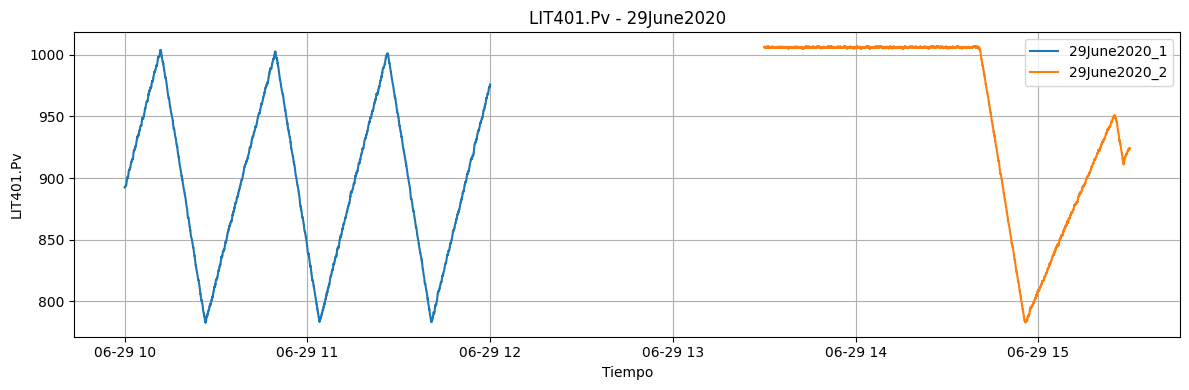

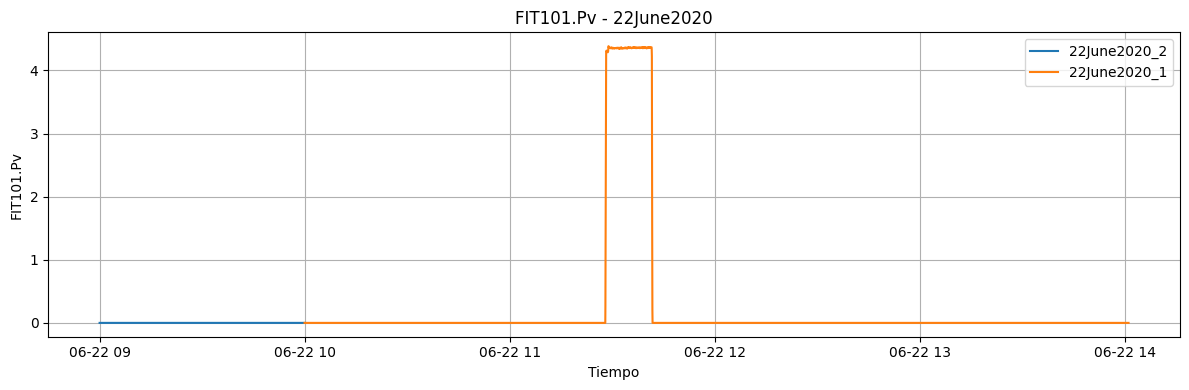

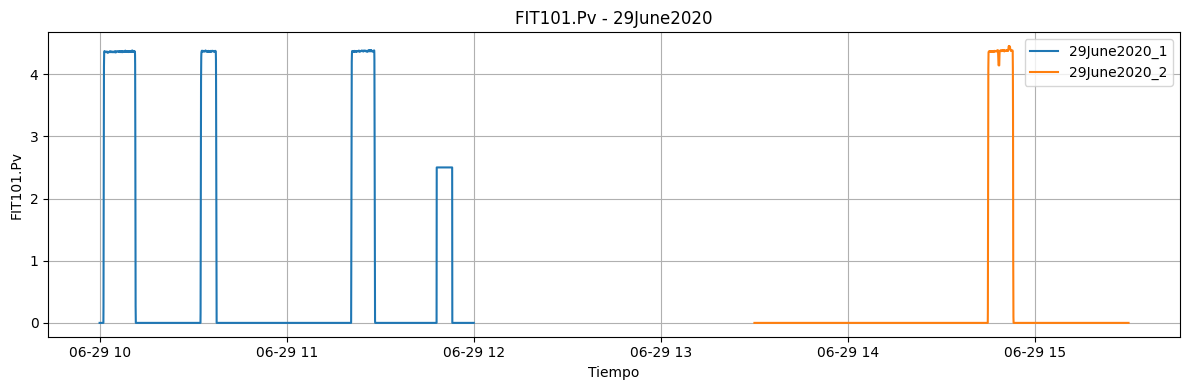

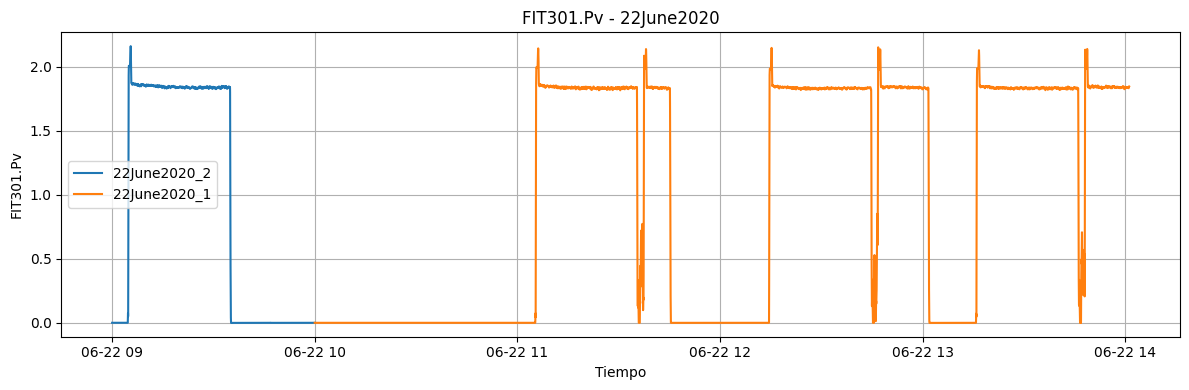

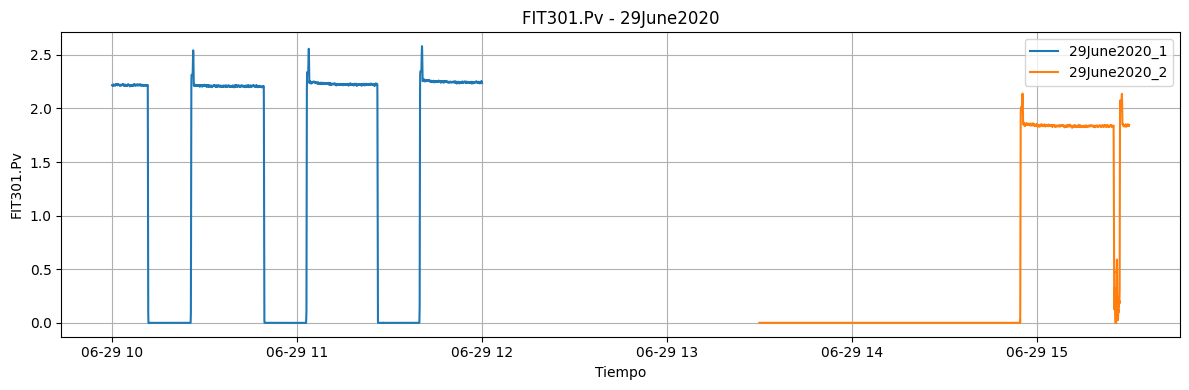

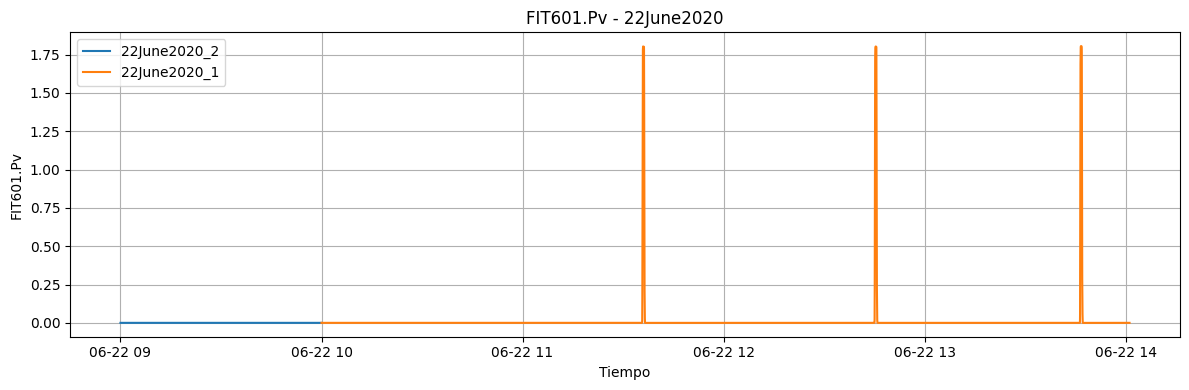

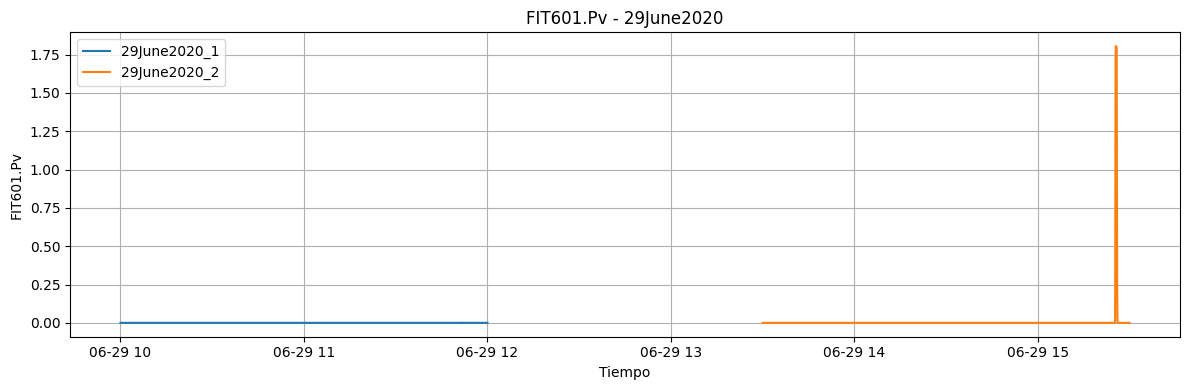

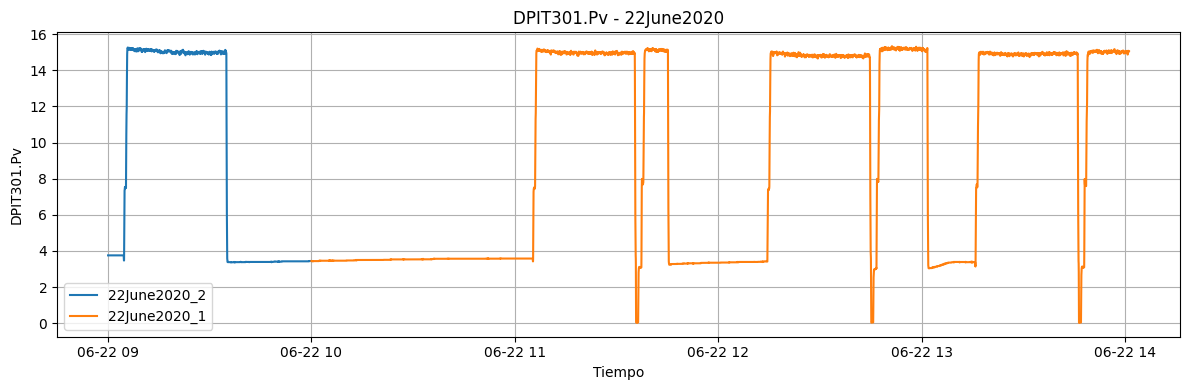

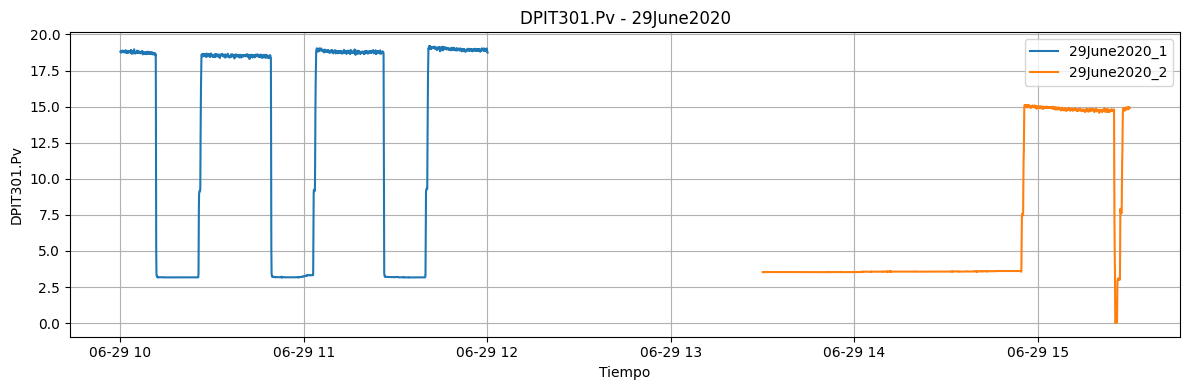

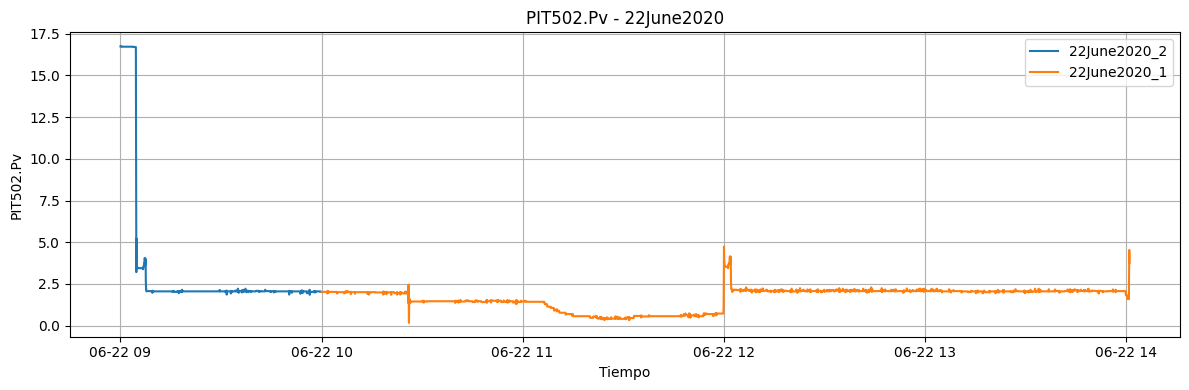

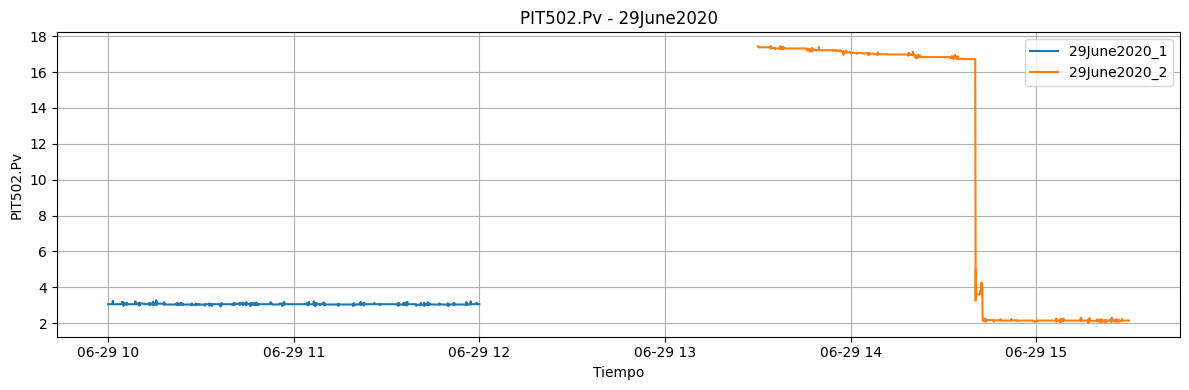

In [10]:
sensors_to_review = [
    "AIT201.Pv", "AIT202.Pv", "AIT203.Pv",
    "LIT101.Pv", "LIT301.Pv", "LIT401.Pv",
    "FIT101.Pv", "FIT301.Pv", "FIT601.Pv",
    "DPIT301.Pv", "PIT502.Pv"
]

for sensor in sensors_to_review:
    plot_sensor_time_series_by_day(files, sensor)

## Perfilamiento por columna

In [11]:
profile_rows = []

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0).reset_index(drop=True)

for col in feature_cols:
    s = global_df[col]
    profile_rows.append({
        "feature": col,
        "type": "continuous" if col in continuous_cols else "discrete",
        "n_unique": s.nunique(dropna=True),
        "missing": int(s.isna().sum()),
        "is_constant": s.nunique(dropna=True) <= 1,
        "min": s.min() if col in continuous_cols else np.nan,
        "max": s.max() if col in continuous_cols else np.nan,
        "mean": s.mean() if col in continuous_cols else np.nan,
        "std": s.std() if col in continuous_cols else np.nan
    })

profile_df = pd.DataFrame(profile_rows)
profile_df

,feature,type,n_unique,missing,is_constant,min,max,mean,std
0,AIT201.Pv,continuous,1817,0,False,6.729044,117.405792,4.538645e+01,3.333202e+01
1,AIT202.Pv,continuous,5838,0,False,6.525122,9.695784,8.194726e+00,8.985818e-01
2,AIT203.Pv,continuous,2954,0,False,13.919508,177.108429,1.379827e+02,2.993334e+01
3,AIT401.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
4,AIT402.Pv,continuous,1,0,True,0.000000,0.000000,0.000000e+00,0.000000e+00
5,AIT501.Pv,continuous,1369,0,False,7.177519,7.747885,7.449547e+00,1.689963e-01
6,AIT502.Pv,continuous,1282,0,False,146.936676,260.000000,1.876159e+02,4.132093e+01
7,AIT503.Pv,continuous,613,0,False,28.101768,79.851320,4.998782e+01,1.498397e+01
8,AIT504.Pv,continuous,358,0,False,0.038452,101.473984,2.353729e+00,4.103129e+00
9,DPIT301.Pv,continuous,1125,0,False,0.016006,19.191370,9.576453e+00,6.394101e+00


## Eliminar columnas constantes

In [12]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()
constant_cols

['AIT401.Pv',
 'AIT402.Pv',
 'P102.Status',
 'P202.Status',
 'P204.Status',
 'P206.Status',
 'P302.Status',
 'P402.Status',
 'P403.Status',
 'P404.Status',
 'P502.Status']

In [13]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols

print("Continuas restantes:", len(continuous_cols))
print("Discretas restantes:", len(discrete_cols))

Continuas restantes: 23
Discretas restantes: 26


## Warm-up

In [14]:
WARMUP = 120  # segundos

def remove_warmup(df, warmup_seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    start_time = df["t_stamp"].min()
    return df[df["t_stamp"] >= start_time + pd.Timedelta(seconds=warmup_seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], warmup_seconds=WARMUP)

## Split temporal por archivo

In [15]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [16]:
split_by_file = {}

for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()

    train_i, val_i, test_i = temporal_split(df_base)

    split_by_file[name] = {
        "train": train_i,
        "val": val_i,
        "test": test_i
    }

    print(f"{name}:")
    print("  train:", train_i.shape)
    print("  val:  ", val_i.shape)
    print("  test: ", test_i.shape)

22June2020_1:
  train: (8568, 50)
  val:   (2856, 50)
  test:  (2856, 50)
22June2020_2:
  train: (2088, 50)
  val:   (696, 50)
  test:  (696, 50)
29June2020_1:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1417, 50)
29June2020_2:
  train: (4248, 50)
  val:   (1416, 50)
  test:  (1416, 50)


## Dataframes globales por split

In [17]:
train_df = pd.concat(
    [split_by_file[name]["train"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

val_df = pd.concat(
    [split_by_file[name]["val"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

test_df = pd.concat(
    [split_by_file[name]["test"][feature_cols] for name in split_by_file],
    axis=0
).reset_index(drop=True)

print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

train: (19152, 49)
val:   (6384, 49)
test:  (6385, 49)


## Escalado solo continuas

In [18]:
scaler_cont = StandardScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file],
    axis=0
)

scaler_cont.fit(train_all_cont)

,copy,True
,with_mean,True
,with_std,True


In [19]:
def scale_split_part(df_part, scaler_cont, continuous_cols, discrete_cols):
    cont = pd.DataFrame(
        scaler_cont.transform(df_part[continuous_cols]),
        columns=continuous_cols,
        index=df_part.index
    )

    disc = df_part[discrete_cols].copy()

    return cont, disc

In [20]:
scaled_split_by_file = {}

for name in split_by_file:
    scaled_split_by_file[name] = {}

    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]

        cont_part, disc_part = scale_split_part(
            df_part=df_part,
            scaler_cont=scaler_cont,
            continuous_cols=continuous_cols,
            discrete_cols=discrete_cols
        )

        scaled_split_by_file[name][subset] = {
            "cont": cont_part,
            "disc": disc_part
        }

## Crear ventanas sin mezclar archivos

In [21]:
def build_windows_with_origin(scaled_split_by_file, subset, window_size=60, stride=5):
    cont_windows = []
    disc_windows = []
    origin_tracker = []

    for name in scaled_split_by_file:
        cont_df = scaled_split_by_file[name][subset]["cont"]
        disc_df = scaled_split_by_file[name][subset]["disc"]

        if len(cont_df) < window_size:
            continue

        cont_arr = cont_df.values
        disc_arr = disc_df.values

        for i in range(0, len(cont_df) - window_size + 1, stride):
            cont_windows.append(cont_arr[i:i+window_size])
            disc_windows.append(disc_arr[i:i+window_size])
            origin_tracker.append(name)

    if len(cont_windows) == 0:
        return (
            np.empty((0, window_size, len(continuous_cols))),
            np.empty((0, window_size, len(discrete_cols))),
            []
        )

    return np.array(cont_windows), np.array(disc_windows), origin_tracker

In [22]:
BEST_PARAMS = {
    "window_size": 30,
    "stride": 1,
    "n_lstm_layers": 1,
    "lstm_hidden": 128,
    "latent_dim": 32,
    "disc_hidden_1": 64,
    "disc_hidden_2": 64,
    "fusion_hidden": 64,
    "dropout": 0.16736980565233767,
    "batch_size": 64,
    "lr": 0.0009519751000279115,
    "optimizer": "AdamW",
    "epochs": 40
}

L = BEST_PARAMS["window_size"]
stride = BEST_PARAMS["stride"]

In [23]:
train_cont_windows, train_disc_windows, train_origin = build_windows_with_origin(
    scaled_split_by_file, subset="train", window_size=L, stride=stride
)

val_cont_windows, val_disc_windows, val_origin = build_windows_with_origin(
    scaled_split_by_file, subset="val", window_size=L, stride=stride
)

test_cont_windows, test_disc_windows, test_origin = build_windows_with_origin(
    scaled_split_by_file, subset="test", window_size=L, stride=stride
)

print("Train cont windows:", train_cont_windows.shape)
print("Train disc windows:", train_disc_windows.shape)

print("Val cont windows:", val_cont_windows.shape)
print("Val disc windows:", val_disc_windows.shape)

print("Test cont windows:", test_cont_windows.shape)
print("Test disc windows:", test_disc_windows.shape)

Train cont windows: (19036, 30, 23)
Train disc windows: (19036, 30, 26)
Val cont windows: (6268, 30, 23)
Val disc windows: (6268, 30, 26)
Test cont windows: (6269, 30, 23)
Test disc windows: (6269, 30, 26)


## Resumen discretas por ventana

In [24]:
def summarize_discrete_windows(disc_windows, discrete_cols):
    summary_rows = []

    for w in disc_windows:
        feats = {}

        for j, col in enumerate(discrete_cols):
            values = w[:, j]

            mode_val = pd.Series(values).mode().iloc[0]
            transitions = np.sum(values[1:] != values[:-1])
            nunique = len(np.unique(values))
            dominance = pd.Series(values).value_counts(normalize=True).iloc[0]

            feats[f"{col}__mode"] = mode_val
            feats[f"{col}__transitions"] = transitions
            feats[f"{col}__nunique"] = nunique
            feats[f"{col}__dominance"] = dominance

        summary_rows.append(feats)

    return pd.DataFrame(summary_rows)

In [25]:
train_disc_summary = summarize_discrete_windows(train_disc_windows, discrete_cols)
val_disc_summary   = summarize_discrete_windows(val_disc_windows, discrete_cols)
test_disc_summary  = summarize_discrete_windows(test_disc_windows, discrete_cols)

print("Train disc summary:", train_disc_summary.shape)
print("Val disc summary:  ", val_disc_summary.shape)
print("Test disc summary: ", test_disc_summary.shape)

Train disc summary: (19036, 104)
Val disc summary:   (6268, 104)
Test disc summary:  (6269, 104)


## Reorganización para LSTM

In [26]:
X_train = train_cont_windows.astype(np.float32)
X_val   = val_cont_windows.astype(np.float32)
X_test  = test_cont_windows.astype(np.float32)

X_train_disc = train_disc_summary.values.astype(np.float32)
X_val_disc   = val_disc_summary.values.astype(np.float32)
X_test_disc  = test_disc_summary.values.astype(np.float32)

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("X_train_disc:", X_train_disc.shape)
print("X_val_disc:  ", X_val_disc.shape)
print("X_test_disc: ", X_test_disc.shape)

X_train: (19036, 30, 23)
X_val:   (6268, 30, 23)
X_test:  (6269, 30, 23)
X_train_disc: (19036, 104)
X_val_disc:   (6268, 104)
X_test_disc:  (6269, 104)


## Tensores y DataLoaders

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [28]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

X_train_disc_tensor = torch.tensor(X_train_disc, dtype=torch.float32)
X_val_disc_tensor   = torch.tensor(X_val_disc, dtype=torch.float32)
X_test_disc_tensor  = torch.tensor(X_test_disc, dtype=torch.float32)

In [29]:
y_train_tensor = X_train_tensor.clone()
y_val_tensor   = X_val_tensor.clone()
y_test_tensor  = X_test_tensor.clone()

In [30]:
train_dataset = TensorDataset(X_train_tensor, X_train_disc_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, X_val_disc_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, X_test_disc_tensor, y_test_tensor)

In [31]:
BATCH_SIZE = BEST_PARAMS["batch_size"]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Modelo híbrido LSTM + MLP

In [32]:
class HybridLSTMAutoencoder(nn.Module):
    def __init__(
        self,
        cont_dim,
        seq_len,
        disc_dim,
        n_lstm_layers=1,
        lstm_hidden=64,
        latent_dim=32,
        disc_hidden_1=64,
        disc_hidden_2=16,
        fusion_hidden=128,
        dropout=0.1
    ):
        super().__init__()

        self.cont_dim = cont_dim
        self.seq_len = seq_len
        self.disc_dim = disc_dim
        self.n_lstm_layers = n_lstm_layers
        self.lstm_hidden = lstm_hidden
        self.latent_dim = latent_dim

        self.encoder_lstm = nn.LSTM(
            input_size=cont_dim,
            hidden_size=lstm_hidden,
            num_layers=n_lstm_layers,
            batch_first=True,
            dropout=dropout if n_lstm_layers > 1 else 0.0
        )

        self.encoder_proj = nn.Sequential(
            nn.Linear(lstm_hidden, latent_dim),
            nn.ReLU()
        )

        self.encoder_disc = nn.Sequential(
            nn.Linear(disc_dim, disc_hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(disc_hidden_1, disc_hidden_2),
            nn.ReLU()
        )

        self.fusion = nn.Sequential(
            nn.Linear(latent_dim + disc_hidden_2, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, latent_dim),
            nn.ReLU()
        )

        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, lstm_hidden),
            nn.ReLU()
        )

        self.decoder_lstm = nn.LSTM(
            input_size=lstm_hidden,
            hidden_size=lstm_hidden,
            num_layers=n_lstm_layers,
            batch_first=True,
            dropout=dropout if n_lstm_layers > 1 else 0.0
        )

        self.output_layer = nn.Linear(lstm_hidden, cont_dim)

    def forward(self, x_cont, x_disc):
        _, (h_n, _) = self.encoder_lstm(x_cont)
        z_cont = self.encoder_proj(h_n[-1])

        z_disc = self.encoder_disc(x_disc)

        z = torch.cat([z_cont, z_disc], dim=1)
        z_fused = self.fusion(z)

        decoder_seed = self.decoder_input(z_fused)
        decoder_seq = decoder_seed.unsqueeze(1).repeat(1, self.seq_len, 1)

        decoded_seq, _ = self.decoder_lstm(decoder_seq)
        x_hat = self.output_layer(decoded_seq)

        return x_hat

In [33]:
cont_dim = X_train.shape[2]
seq_len = X_train.shape[1]
disc_dim = X_train_disc.shape[1]

model = HybridLSTMAutoencoder(
    cont_dim=cont_dim,
    seq_len=seq_len,
    disc_dim=disc_dim,
    n_lstm_layers=BEST_PARAMS["n_lstm_layers"],
    lstm_hidden=BEST_PARAMS["lstm_hidden"],
    latent_dim=BEST_PARAMS["latent_dim"],
    disc_hidden_1=BEST_PARAMS["disc_hidden_1"],
    disc_hidden_2=BEST_PARAMS["disc_hidden_2"],
    fusion_hidden=BEST_PARAMS["fusion_hidden"],
    dropout=BEST_PARAMS["dropout"]
).to(device)

model

HybridLSTMAutoencoder(
  (encoder_lstm): LSTM(23, 128, batch_first=True)
  (encoder_proj): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
  )
  (encoder_disc): Sequential(
    (0): Linear(in_features=104, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.16736980565233767, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (fusion): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.16736980565233767, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  )
  (decoder_input): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder_lstm): LSTM(128, 128, batch_first=True)
  (output_layer): Linear(in_features=128, out_features=23, bias=True)
)

## Loss y optimizador

In [34]:
criterion = nn.L1Loss()

if BEST_PARAMS["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=BEST_PARAMS["lr"])
elif BEST_PARAMS["optimizer"] == "AdamW":
    optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_PARAMS["lr"])
else:
    raise ValueError(f"Optimizador no soportado: {BEST_PARAMS['optimizer']}")

## Entrenamiento

In [35]:
def train_hybrid_lstm_autoencoder(model, train_loader, val_loader, criterion, optimizer, device, epochs=30):
    loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x_cont_batch, x_disc_batch, y_batch in train_loader:
            x_cont_batch = x_cont_batch.to(device)
            x_disc_batch = x_disc_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_hat = model(x_cont_batch, x_disc_batch)
            loss = criterion(y_hat, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        loss_history.append(train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for x_cont_batch, x_disc_batch, y_batch in val_loader:
                x_cont_batch = x_cont_batch.to(device)
                x_disc_batch = x_disc_batch.to(device)
                y_batch = y_batch.to(device)

                y_hat = model(x_cont_batch, x_disc_batch)
                loss = criterion(y_hat, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_history.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")

    return loss_history, val_loss_history

In [36]:
EPOCHS = BEST_PARAMS["epochs"]

loss_history, val_loss_history = train_hybrid_lstm_autoencoder(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS
)

Epoch [1/40] - Train Loss: 0.273120 - Val Loss: 0.385543
Epoch [2/40] - Train Loss: 0.106491 - Val Loss: 0.369406
Epoch [3/40] - Train Loss: 0.080364 - Val Loss: 0.402955
Epoch [4/40] - Train Loss: 0.068202 - Val Loss: 0.399607
Epoch [5/40] - Train Loss: 0.065257 - Val Loss: 0.396080
Epoch [6/40] - Train Loss: 0.063986 - Val Loss: 0.384425
Epoch [7/40] - Train Loss: 0.057280 - Val Loss: 0.388386
Epoch [8/40] - Train Loss: 0.055926 - Val Loss: 0.357303
Epoch [9/40] - Train Loss: 0.053277 - Val Loss: 0.377335
Epoch [10/40] - Train Loss: 0.054031 - Val Loss: 0.343233
Epoch [11/40] - Train Loss: 0.048144 - Val Loss: 0.354157
Epoch [12/40] - Train Loss: 0.047057 - Val Loss: 0.324509
Epoch [13/40] - Train Loss: 0.042941 - Val Loss: 0.340636
Epoch [14/40] - Train Loss: 0.039961 - Val Loss: 0.342792
Epoch [15/40] - Train Loss: 0.042791 - Val Loss: 0.335518
Epoch [16/40] - Train Loss: 0.037493 - Val Loss: 0.360856
Epoch [17/40] - Train Loss: 0.037111 - Val Loss: 0.318342
Epoch [18/40] - Train L

## Curva de entrenamiento

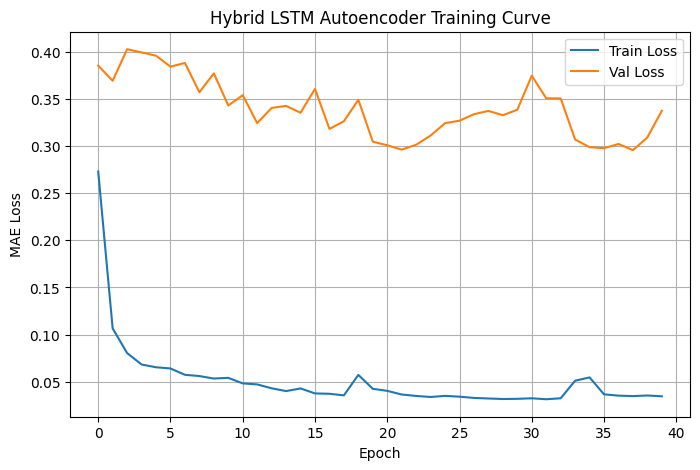

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("Hybrid LSTM Autoencoder Training Curve")
plt.grid(True)
plt.legend()
plt.show()

## Errores de reconstrucción

In [38]:
def compute_reconstruction_errors(model, data_loader, device):
    model.eval()
    errors = []

    with torch.no_grad():
        for x_cont_batch, x_disc_batch, y_batch in data_loader:
            x_cont_batch = x_cont_batch.to(device)
            x_disc_batch = x_disc_batch.to(device)
            y_batch = y_batch.to(device)

            y_hat = model(x_cont_batch, x_disc_batch)
            batch_error = torch.mean(torch.abs(y_hat - y_batch), dim=(1, 2))
            errors.extend(batch_error.cpu().numpy())

    return np.array(errors)

In [39]:
val_reconstruction_errors = compute_reconstruction_errors(model, val_loader, device)
test_reconstruction_errors = compute_reconstruction_errors(model, test_loader, device)

print("Validation errors shape:", val_reconstruction_errors.shape)
print("Validation error mean:", val_reconstruction_errors.mean())
print("Validation error std:", val_reconstruction_errors.std())

print("\nTest errors shape:", test_reconstruction_errors.shape)
print("Test error mean:", test_reconstruction_errors.mean())
print("Test error std:", test_reconstruction_errors.std())

Validation errors shape: (6268,)
Validation error mean: 0.33765545
Validation error std: 0.2589915

Test errors shape: (6269,)
Test error mean: 0.26898322
Test error std: 0.23497447


## Histogramas

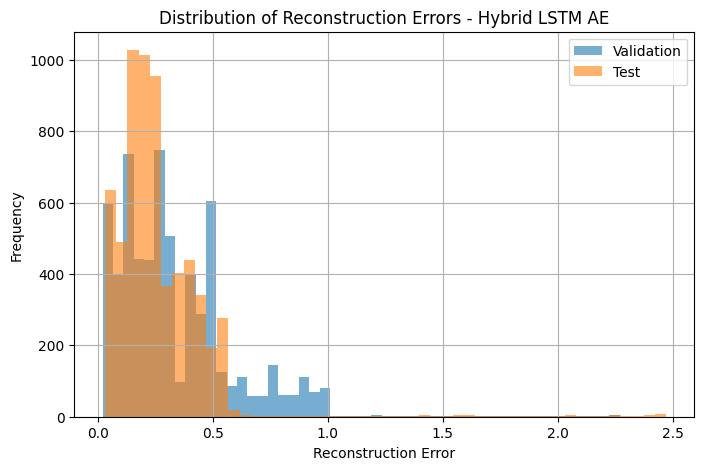

In [40]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=50, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=50, alpha=0.6, label="Test")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors - Hybrid LSTM AE")
plt.legend()
plt.grid(True)
plt.show()

## Tau y FAR

In [41]:
percentiles = [90, 95, 97.5, 99, 99.5]

tau_dict = {
    p: np.percentile(val_reconstruction_errors, p)
    for p in percentiles
}

tau_df = pd.DataFrame({
    "percentile": list(tau_dict.keys()),
    "tau": list(tau_dict.values())
})

tau_df

,percentile,tau
0,90.0,0.698187
1,95.0,0.869430
2,97.5,0.950827
3,99.0,0.980497
4,99.5,1.348407


In [42]:
far_rows = []

for p, tau in tau_dict.items():
    far_val = np.mean(val_reconstruction_errors > tau)
    far_test = np.mean(test_reconstruction_errors > tau)

    far_rows.append({
        "percentile": p,
        "tau": tau,
        "FAR_val": far_val,
        "FAR_test": far_test,
        "FAR_val_pct": round(far_val * 100, 2),
        "FAR_test_pct": round(far_test * 100, 2)
    })

far_df = pd.DataFrame(far_rows)
far_df

,percentile,tau,FAR_val,FAR_test,FAR_val_pct,FAR_test_pct
0,90.0,0.698187,0.100032,0.016271,10.00,1.63
1,95.0,0.869430,0.050096,0.014994,5.01,1.50
2,97.5,0.950827,0.025048,0.014516,2.50,1.45
3,99.0,0.980497,0.010051,0.014197,1.01,1.42
4,99.5,1.348407,0.005105,0.011485,0.51,1.15


## Guardado

In [43]:
MODEL_NAME = "lstm_hybrid_ae"

base_model_dir = Path(f"../models/detectors/{MODEL_NAME}")
base_model_dir.mkdir(parents=True, exist_ok=True)

scaler_dir = Path("../artifacts/scalers")
scaler_dir.mkdir(parents=True, exist_ok=True)

metadata_dir = Path("../artifacts/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

metrics_dir = Path("../artifacts/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

In [44]:
torch.save(model.state_dict(), base_model_dir / "model_state.pt")

joblib.dump(scaler_cont, scaler_dir / f"{MODEL_NAME}_scaler_cont.pkl")

['..\\artifacts\\scalers\\lstm_hybrid_ae_scaler_cont.pkl']

In [45]:
config = {
    "model_name": MODEL_NAME,
    "best_params_from_optuna": BEST_PARAMS,
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": L,
    "stride": stride,
    "warmup": WARMUP,
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "loss_function": criterion.__class__.__name__,
    "optimizer": optimizer.__class__.__name__,
    "learning_rate": optimizer.param_groups[0]["lr"],

    "train_shape": list(train_df.shape),
    "val_shape": list(val_df.shape),
    "test_shape": list(test_df.shape),

    "train_cont_windows_shape": list(train_cont_windows.shape),
    "val_cont_windows_shape": list(val_cont_windows.shape),
    "test_cont_windows_shape": list(test_cont_windows.shape),

    "train_disc_windows_shape": list(train_disc_windows.shape),
    "val_disc_windows_shape": list(val_disc_windows.shape),
    "test_disc_windows_shape": list(test_disc_windows.shape),

    "X_train_shape": list(X_train.shape),
    "X_val_shape": list(X_val.shape),
    "X_test_shape": list(X_test.shape),

    "X_train_disc_shape": list(X_train_disc.shape),
    "X_val_disc_shape": list(X_val_disc.shape),
    "X_test_disc_shape": list(X_test_disc.shape),

    "train_disc_summary_shape": list(train_disc_summary.shape),
    "val_disc_summary_shape": list(val_disc_summary.shape),
    "test_disc_summary_shape": list(test_disc_summary.shape),
}

with open(base_model_dir / "config.json", "w") as f:
    json.dump(config, f, indent=4)

In [46]:
tau_dict_serializable = {str(k): float(v) for k, v in tau_dict.items()}

with open(base_model_dir / "tau_dict.json", "w") as f:
    json.dump(tau_dict_serializable, f, indent=4)

In [47]:
if "far_df" in globals():
    far_df.to_csv(base_model_dir / "metrics.csv", index=False)
    far_df.to_csv(metrics_dir / f"{MODEL_NAME}_far.csv", index=False)

if "loss_history" in globals() and "val_loss_history" in globals():
    loss_df = pd.DataFrame({
        "epoch": list(range(1, len(loss_history) + 1)),
        "train_loss": loss_history,
        "val_loss": val_loss_history
    })
    loss_df.to_csv(base_model_dir / "loss_history.csv", index=False)

print(f"Artefactos guardados correctamente para {MODEL_NAME}")
print(f"Ruta: {base_model_dir.resolve()}")

Artefactos guardados correctamente para lstm_hybrid_ae
Ruta: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\lstm_hybrid_ae
